IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    precision_recall_curve, 
    classification_report)

from xgboost import XGBClassifier

LOAD DATASET

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = df.drop("Class", axis=1)
y = df["Class"]

SPLIT TRAIN AND TEST

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            stratify=y, 
            test_size=0.3, 
            random_state=42
)

# HANDLE IMBALANCE
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


PIPELINE XGBoost

In [18]:
Pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("Model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        random_state=42
    ))
])

HYPERPARAMETER

In [19]:
param_dict = {
    "Model__n_estimators" : [100, 200, 300],
    "Model__max_depth" : [3,5,7],
    "Model__learning_rate" : [0.01, 0.05, 0.1],
    "Model__subsample" : [0.8, 1.0],
    "Model__colsample_bytree" : [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    Pipeline,
    param_distributions=param_dict,
    n_iter=20,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    verbose=1,
    n_jobs=-1
)

Train

In [20]:
search.fit(X_train, y_train)

best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Satri\Downloads\dataset gambar\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:46:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


EVALUATION

In [23]:
y_probs_xgb = best_model.predict_proba(X_test)[:, 1]

roc_xgb = roc_auc_score(y_test, y_probs_xgb)
pr_xgb = average_precision_score(y_test, y_probs_xgb)

print(f"ROC-AUC: {roc_xgb:.4f}")
print(f"PR-AUC: {pr_xgb:.4f}")

ROC-AUC: 0.9750
PR-AUC: 0.8359


In [24]:
threshold = 0.5
y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_xgb)
print(cm_rf)

[[85281    14]
 [   30   118]]


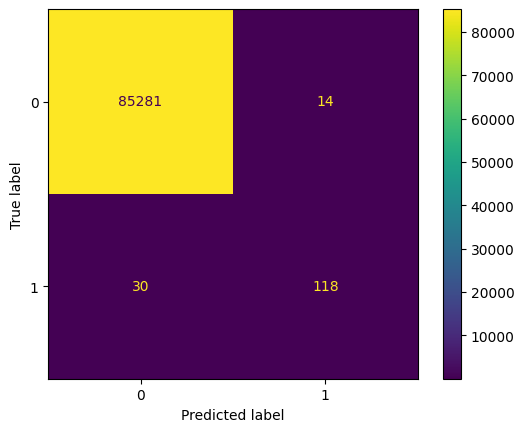

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

SHAP XGB

In [26]:
xgb_model = best_model.named_steps["Model"]

X_train_scaled = best_model.named_steps["scaler"].transform(X_train)
X_test_scaled = best_model.named_steps["scaler"].transform(X_test)

import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

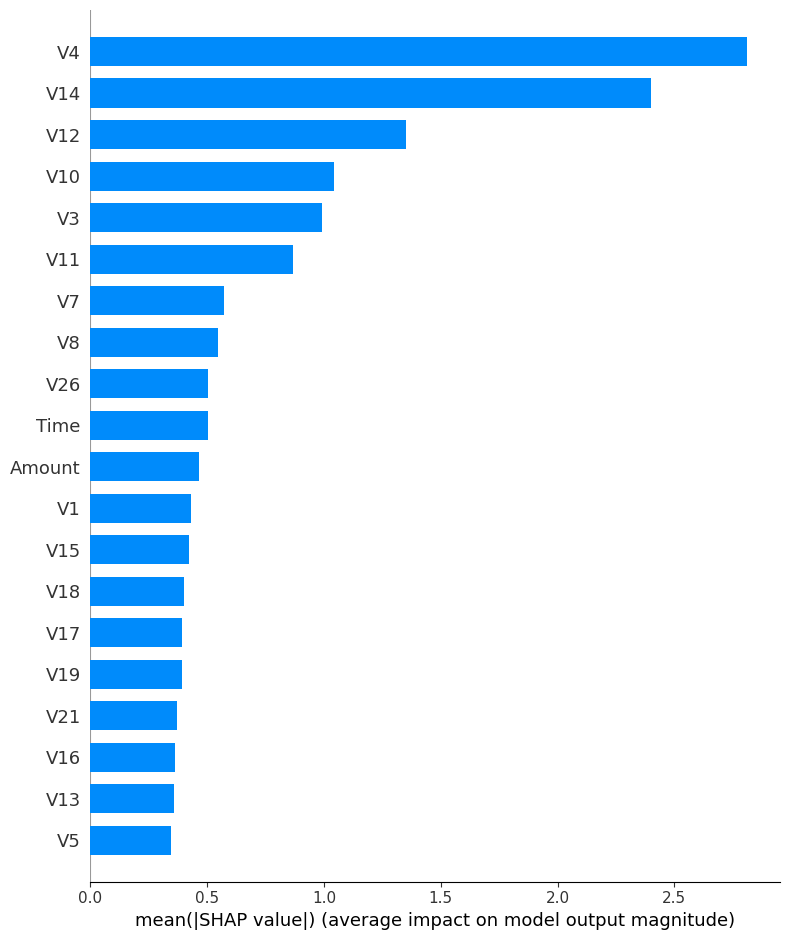

In [28]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns,
    plot_type="bar"
)

RANDOM FOREST

IMPORT LIBRARY

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

MODEL AND IMBALANCE HANDLING

In [11]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),  # optional for RF, but keep consistency
    ("model", RandomForestClassifier(
        class_weight="balanced",   # CRITICAL
        random_state=42,
        n_jobs=-1
    ))
])

HYPERPARAMETER SPACE

In [12]:
rf_param_dist = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

CROSS VALIDATION

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

TRAIN

In [14]:
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


EVALUATION

In [15]:
y_probs_rf = rf_best.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_probs_rf)
pr_rf = average_precision_score(y_test, y_probs_rf)

print(f"RF ROC-AUC: {roc_rf:.4f}")
print(f"RF PR-AUC: {pr_rf:.4f}")

RF ROC-AUC: 0.9359
RF PR-AUC: 0.8199


In [16]:
threshold = 0.5
y_pred_rf = (y_probs_rf >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[85291     4]
 [   37   111]]


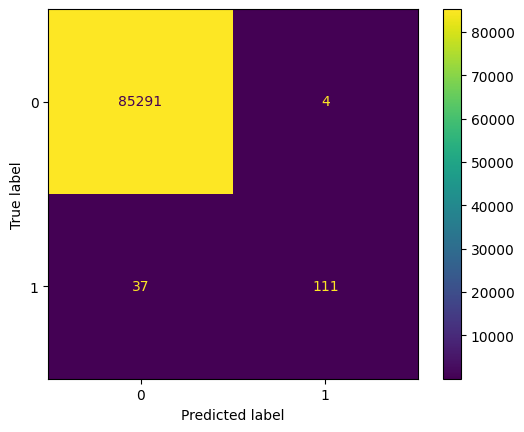

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

SHAP RF

In [32]:
rf_model = rf_best.named_steps["model"]

X_train_scaled = rf_best.named_steps["scaler"].transform(X_train)
X_test_scaled = rf_best.named_steps["scaler"].transform(X_test)

import shap

explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer.shap_values(X_test_scaled)

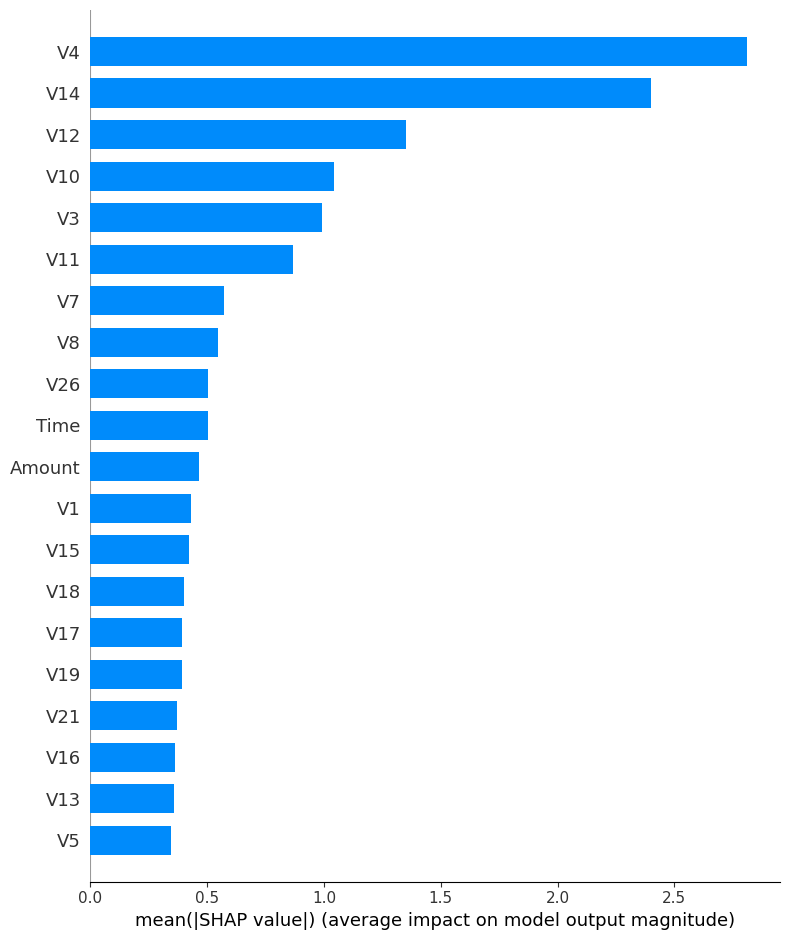

In [33]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns,
    plot_type="bar"
)